# EE 446 Homework 1 Programming Notebook

Use the **tinyml-arduino** Python environment that you set up for this class. In JupyterLab, select the kernel named **Python (tinyml-arduino)** before running this notebook.

Do not install or uninstall TensorFlow packages inside this notebook. The class environment already contains the required packages for this assignment, including TensorFlow, TensorFlow Model Optimization Toolkit, scikit-learn, NumPy, pandas, and JupyterLab.

This notebook contains the programming questions marked **[Pro]**. Complete each section by replacing the placeholder comments with your own code. Print the requested outputs so that your work can be graded directly from the notebook.


In [2]:
import sys
print(sys.executable)

/Users/jimmyzheng/ai/projects/tinyml-arduino/bin/python


In [3]:
import sys
!{sys.executable} -m pip install "tensorflow-model-optimization==0.8.0"


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import sys
!{sys.executable} -m pip install "keras==2.14.0"


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, r2_score, accuracy_score, ConfusionMatrixDisplay

import tensorflow as tf
import tensorflow_model_optimization as tfmot

Sequential = tf.keras.Sequential
Dense = tf.keras.layers.Dense
LSTM = tf.keras.layers.LSTM
to_categorical = tf.keras.utils.to_categorical

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0



---

# Problem 1: DNN and Wine Classification (80 points)

This problem uses the Wine dataset available through scikit-learn. The dataset is loaded locally from the installed package, so no external data file is required.


In [6]:
# Load the Wine dataset from scikit-learn.
# This avoids requiring an external wine.data file.

wine = load_wine(as_frame=True)

feature_names = list(wine.feature_names)
df = wine.frame.copy()
df["Class"] = wine.target

# Reorder the columns so that the class label appears first.
df = df[["Class"] + feature_names]

# Number of classes
num_classes = df["Class"].nunique()
print("Number of classes:", num_classes)

# Number of features, excluding the class label
num_features = df.shape[1] - 1
print("Number of features:", num_features)

# Basic feature statistics
feature_stats = df.drop(columns=["Class"]).describe().T[["min", "max", "mean", "std"]]
print("\nFeature statistics:\n", feature_stats)

# Class distribution
class_counts = df["Class"].value_counts().sort_index()
print("\nClass distribution:\n", class_counts)


Number of classes: 3
Number of features: 13

Feature statistics:
                                  min      max        mean         std
alcohol                        11.03    14.83   13.000618    0.811827
malic_acid                      0.74     5.80    2.336348    1.117146
ash                             1.36     3.23    2.366517    0.274344
alcalinity_of_ash              10.60    30.00   19.494944    3.339564
magnesium                      70.00   162.00   99.741573   14.282484
total_phenols                   0.98     3.88    2.295112    0.625851
flavanoids                      0.34     5.08    2.029270    0.998859
nonflavanoid_phenols            0.13     0.66    0.361854    0.124453
proanthocyanins                 0.41     3.58    1.590899    0.572359
color_intensity                 1.28    13.00    5.058090    2.318286
hue                             0.48     1.71    0.957449    0.228572
od280/od315_of_diluted_wines    1.27     4.00    2.611685    0.709990
proline                 

## Problem 1 - Part (a)
### Base Model Training and Evaluation


In [7]:
# Step 1: Separate the feature matrix and class labels.
# - Assign the feature columns to variable X.
# - Assign the class labels to variable y.
# - The labels in this scikit-learn dataset are already zero-based: 0, 1, and 2.

X = df.drop(columns=["Class"]).values
y = df["Class"].values


In [8]:
# Step 2: Perform a train-test split (70% train, 30% test) using random_state=42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [9]:
# Step 3: Use StandardScaler to normalize the features
# - Fit on X_train and transform both X_train and X_test

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
# Step 4: Use one-hot encoding for y_train and y_test.
# - Use tf.keras.utils.to_categorical.
# - Use num_classes=num_classes to make the output shape explicit.

y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)

In [11]:
# Step 5: Define a Sequential model with the following architecture:
# - Dense(64, activation='relu')
# - Dense(32, activation='relu')
# - Dense(num_classes, activation='softmax')
# Make sure the first Dense layer receives the correct input shape.

model = Sequential([
    Dense(64, activation="relu", input_shape=(num_features,)),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax"),
])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                896       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 3)                 99        
                                                                 
Total params: 3075 (12.01 KB)
Trainable params: 3075 (12.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [12]:
# Step 6: Compile using Adam optimizer, categorical_crossentropy loss, and accuracy metric
# - Train for 20 epochs with batch_size=8 and validation_split=0.2

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    X_train,
    y_train_cat,
    epochs=20,
    batch_size=8,
    validation_split=0.2,
    verbose=1,
)

print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")

Epoch 1/20
13/13 [==============================] - 0s 5ms/step - loss: 0.9190 - accuracy: 0.5152 - val_loss: 0.7705 - val_accuracy: 0.6400
Epoch 2/20
13/13 [==============================] - 0s 944us/step - loss: 0.6841 - accuracy: 0.8687 - val_loss: 0.5753 - val_accuracy: 0.9200
Epoch 3/20
13/13 [==============================] - 0s 929us/step - loss: 0.4977 - accuracy: 0.9495 - val_loss: 0.4223 - val_accuracy: 1.0000
Epoch 4/20
13/13 [==============================] - 0s 857us/step - loss: 0.3436 - accuracy: 0.9697 - val_loss: 0.3080 - val_accuracy: 0.9600
Epoch 5/20
13/13 [==============================] - 0s 867us/step - loss: 0.2345 - accuracy: 0.9798 - val_loss: 0.2371 - val_accuracy: 0.9600
Epoch 6/20
13/13 [==============================] - 0s 886us/step - loss: 0.1611 - accuracy: 0.9899 - val_loss: 0.1945 - val_accuracy: 0.9600
Epoch 7/20
13/13 [==============================] - 0s 945us/step - loss: 0.1193 - accuracy: 0.9899 - val_loss: 0.1750 - val_accuracy: 0.9600
Epoch 8/

Test accuracy: 0.9815

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      0.95      0.98        21
           2       0.94      1.00      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



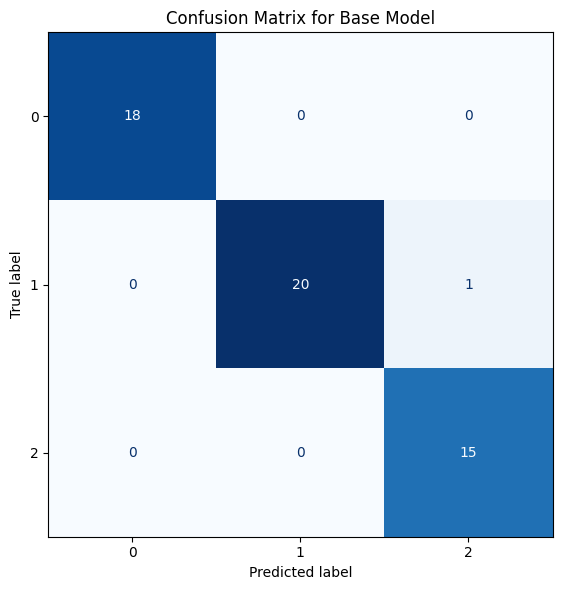

In [13]:
# Step 7: Evaluate the model on test data and print:
# - Accuracy
# - Classification report
# - Confusion matrix

test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix for Base Model")
plt.tight_layout()
plt.show()

In [14]:
# Step 8: Convert the trained model to TFLite format and save it as "model_base.tflite"
# - Print the file size in kilobytes

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_path = "model_base.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024.0
print(f"TFLite model saved to: {tflite_path}")
print(f"Model size: {size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp8r2wsxfr/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp8r2wsxfr/assets
2026-05-07 18:19:56.383864: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-07 18:19:56.383879: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


TFLite model saved to: model_base.tflite
Model size: 14.07 KB


2026-05-07 18:19:56.384166: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp8r2wsxfr
2026-05-07 18:19:56.384506: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-07 18:19:56.384510: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp8r2wsxfr
2026-05-07 18:19:56.385718: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-05-07 18:19:56.386033: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-07 18:19:56.401791: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp8r2wsxfr
2026-05-07 18:19:56.405570: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 

In [15]:
print(f"Final answer to 1(a): ")
print(f"Training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Model size: {size_kb:.2f} KB")

Final answer to 1(a): 
Training accuracy: 1.0000
Test accuracy: 0.9815
Model size: 14.07 KB


## Problem 1 - Part (b)

### Quantization (int8, float16, dynamic range)


In [16]:
def representative_data_gen(X_reference, num_samples=100):
    """Create a representative dataset generator for full integer quantization."""
    max_samples = min(num_samples, len(X_reference))
    for i in range(max_samples):
        yield [X_reference[i:i + 1].astype(np.float32)]


def quantize_and_evaluate(model, X_test, y_test_cat, quant_type, filename):
    """Convert a Keras model to TFLite, evaluate it, and report model size.

    Parameters
    ----------
    model : tf.keras.Model
        Trained Keras model.
    X_test : np.ndarray
        Test features after the same preprocessing used for training.
    y_test_cat : np.ndarray
        One-hot encoded test labels.
    quant_type : str
        One of: 'int8', 'float16', or 'dynamic'.
    filename : str
        Output TFLite filename.
    """

    # Create the TFLite converter from the trained Keras model.
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    # Step 1: Apply quantization settings.
    if quant_type == 'int8':
        # (a) Enable default optimizations.
        # (b) Provide representative_data_gen(X_train_scaled).
        # (c) Set supported_ops to TFLITE_BUILTINS_INT8.
        # (d) Set inference_input_type and inference_output_type to tf.int8.

        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = lambda: representative_data_gen(X_train)
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8
        pass

    elif quant_type == 'float16':
        # (a) Enable default optimizations.
        # (b) Set supported_types to [tf.float16].

        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]
        pass

    elif quant_type == 'dynamic':
        # (a) Enable default optimizations.

        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        pass

    else:
        raise ValueError("quant_type must be one of: 'int8', 'float16', or 'dynamic'.")

    # Step 2: Convert the model and save it to the provided filename.

    tflite_model = converter.convert()

    with open(filename, "wb") as f:
        f.write(tflite_model)

    # Step 3: Run TFLite inference.
    # Complete the following:
    # - Use tf.lite.Interpreter to load the TFLite model.
    # - Allocate tensors.
    # - Get input and output tensor details.
    # - If the input is quantized, quantize each test sample using scale and zero point.
    # - If the output is quantized, dequantize the prediction using scale and zero point.
    # - Collect predictions into y_pred using np.argmax.
    # - Compare with y_true = np.argmax(y_test_cat, axis=1).

    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    
    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]
    
    y_pred = []
    
    for i in range(len(X_test)):
        x = X_test[i:i+1].astype(np.float32)
    
        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])
    
        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()
    
        output = interpreter.get_tensor(output_details["index"])
    
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
    
        y_pred.append(np.argmax(output, axis=1)[0])
    
    y_pred = np.array(y_pred)
    y_true = np.argmax(y_test_cat, axis=1)
    acc = accuracy_score(y_true, y_pred)

    # Step 4: Report results.
    print(f"TFLite model size: {len(tflite_model) / 1024.0:.2f} KB")

    print(f"test accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    
    return acc, y_pred


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp1xk03r75/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp1xk03r75/assets


TFLite model size: 5.74 KB
test accuracy: 0.9815

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      0.95      0.98        21
           2       0.94      1.00      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54


Confusion Matrix:


/Users/jimmyzheng/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-07 18:19:58.743112: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-07 18:19:58.743122: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-07 18:19:58.743204: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp1xk03r75
2026-05-07 18:19:58.743532: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-07 18:19:58.743536: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp1xk03r75
2026-05-07 18:19:58.744420: I tensorflow/cc/saved_model/loader.cc:23

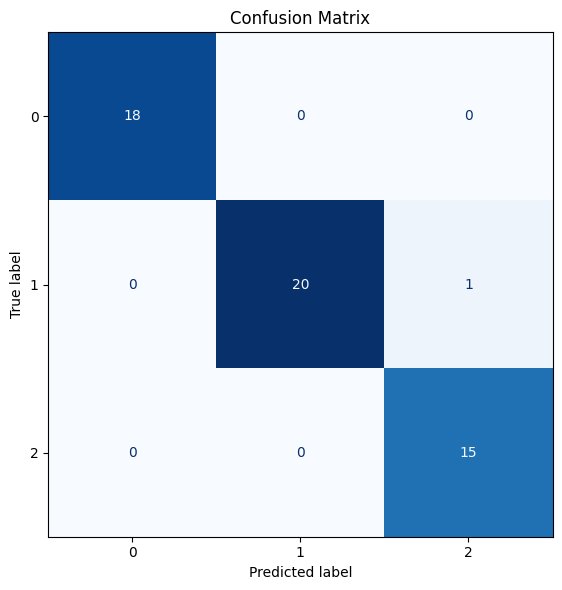

INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp6h51futv/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp6h51futv/assets


TFLite model size: 8.95 KB
test accuracy: 0.9815

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      0.95      0.98        21
           2       0.94      1.00      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54


Confusion Matrix:


2026-05-07 18:19:59.009933: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-07 18:19:59.009944: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-07 18:19:59.010047: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp6h51futv
2026-05-07 18:19:59.010549: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-07 18:19:59.010553: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp6h51futv
2026-05-07 18:19:59.012571: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-07 18:19:59.027947: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp6h51futv
2026-05-

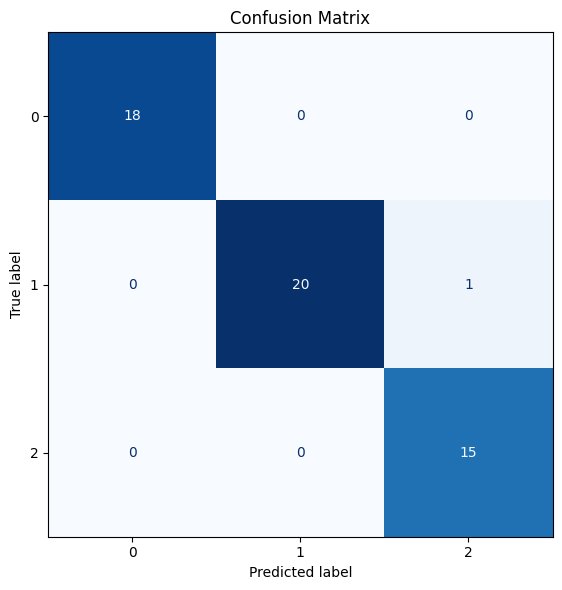

INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp64hnnnoj/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp64hnnnoj/assets


TFLite model size: 8.17 KB
test accuracy: 0.9815

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      0.95      0.98        21
           2       0.94      1.00      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54


Confusion Matrix:


2026-05-07 18:19:59.257776: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-07 18:19:59.257787: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-07 18:19:59.257870: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp64hnnnoj
2026-05-07 18:19:59.258240: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-07 18:19:59.258244: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp64hnnnoj
2026-05-07 18:19:59.259232: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-07 18:19:59.274527: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp64hnnnoj
2026-05-

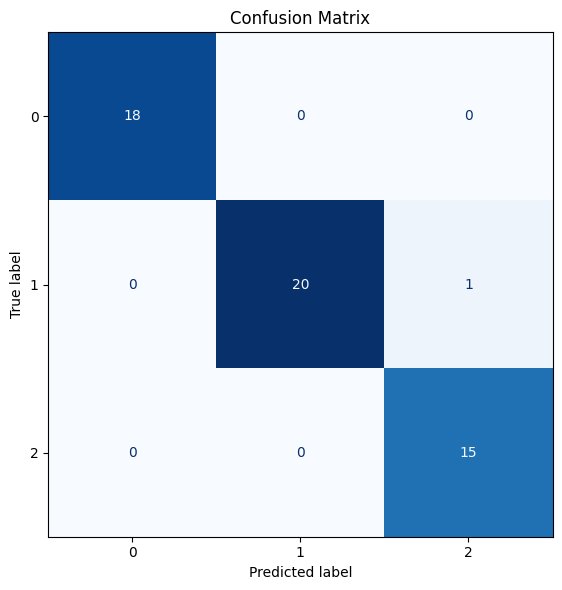

In [17]:
# Step 5: Use the function above to create and evaluate three quantized models:
# - 'int8' saved as 'model_int8.tflite'
# - 'float16' saved as 'model_float16.tflite'
# - 'dynamic' saved as 'model_dynamic.tflite'

int8_acc, int8_pred = quantize_and_evaluate(
    model,
    X_test,
    y_test_cat,
    "int8",
    "model_int8.tflite"
)

float16_acc, float16_pred = quantize_and_evaluate(
    model,
    X_test,
    y_test_cat,
    "float16",
    "model_float16.tflite"
)

dynamic_acc, dynamic_pred = quantize_and_evaluate(
    model,
    X_test,
    y_test_cat,
    "dynamic",
    "model_dynamic.tflite"
)


## Problem 1 - Part (c)

### Pruning

In [18]:
# Step 1: Define a pruning schedule using tfmot.sparsity.keras.PolynomialDecay
# HINT:
# - Use initial_sparsity = 0.5 and final_sparsity = 0.7
# - Set end_step to total training steps (approx. dataset_size / batch_size * epochs)

epochs = 20
batch_size = 8
end_step = int(np.ceil(len(X_train) / batch_size) * epochs)

pruning_params = {
    "pruning_schedule": tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.5,
        final_sparsity=0.7,
        begin_step=0,
        end_step=end_step
    )
}

In [19]:
# Step 2: Build a Sequential model with 3 pruned Dense layers:
# - Dense(64, relu)
# - Dense(32, relu)
# - Dense(3, softmax)
# Make sure each Dense layer is wrapped with prune_low_magnitude()

pruned_model = Sequential([
    tfmot.sparsity.keras.prune_low_magnitude(
        Dense(64, activation="relu", input_shape=(num_features,)),
        **pruning_params
    ),
    tfmot.sparsity.keras.prune_low_magnitude(
        Dense(32, activation="relu"),
        **pruning_params
    ),
    tfmot.sparsity.keras.prune_low_magnitude(
        Dense(3, activation="softmax"),
        **pruning_params
    ),
])

pruned_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_dense_  (None, 64)                1730      
 3 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 32)                4130      
 4 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 3)                 197       
 5 (PruneLowMagnitude)                                           
                                                                 
Total params: 6057 (23.67 KB)
Trainable params: 3075 (12.01 KB)
Non-trainable params: 2982 (11.66 KB)
_________________________________________________________________


In [20]:
# Step 3: Compile the model with categorical_crossentropy and accuracy
# - Train for 10 epochs with batch_size=8 and validation_split=0.2
# - Add tfmot.sparsity.keras.UpdatePruningStep() to the callbacks list

pruned_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep()
]

pruned_history = pruned_model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=8,
    validation_split=0.2,
    callbacks=pruning_callbacks,
    verbose=1,
)

Epoch 1/10
13/13 [==============================] - 1s 5ms/step - loss: 1.1318 - accuracy: 0.4040 - val_loss: 0.8541 - val_accuracy: 0.6000
Epoch 2/10
13/13 [==============================] - 0s 1ms/step - loss: 0.8228 - accuracy: 0.6364 - val_loss: 0.6464 - val_accuracy: 0.8000
Epoch 3/10
13/13 [==============================] - 0s 1ms/step - loss: 0.6427 - accuracy: 0.8081 - val_loss: 0.4989 - val_accuracy: 0.9200
Epoch 4/10
13/13 [==============================] - 0s 990us/step - loss: 0.4976 - accuracy: 0.9091 - val_loss: 0.3853 - val_accuracy: 0.9600
Epoch 5/10
13/13 [==============================] - 0s 974us/step - loss: 0.3768 - accuracy: 0.9697 - val_loss: 0.2918 - val_accuracy: 0.9600
Epoch 6/10
13/13 [==============================] - 0s 1ms/step - loss: 0.2814 - accuracy: 0.9899 - val_loss: 0.2109 - val_accuracy: 0.9600
Epoch 7/10
13/13 [==============================] - 0s 1ms/step - loss: 0.2019 - accuracy: 0.9899 - val_loss: 0.1530 - val_accuracy: 0.9600
Epoch 8/10
13/13

In [21]:
# Step 4: Remove pruning wrappers using tfmot.sparsity.keras.strip_pruning().
# Then convert the stripped model to TFLite and save it as "model_pruned.tflite".
# Print the final file size in KB.

# Important: converting the unstripped pruned model can keep extra pruning variables
# and make the saved model larger than expected.

stripped_model = tfmot.sparsity.keras.strip_pruning(pruned_model)

stripped_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
pruned_tflite_model = converter.convert()

pruned_tflite_path = "model_pruned.tflite"
with open(pruned_tflite_path, "wb") as f:
    f.write(pruned_tflite_model)

pruned_size_kb = len(pruned_tflite_model) / 1024.0
print(f"Pruned TFLite model saved to: {pruned_tflite_path}")
print(f"Pruned model size: {pruned_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmphe6vuv1c/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmphe6vuv1c/assets


Pruned TFLite model saved to: model_pruned.tflite
Pruned model size: 14.14 KB


2026-05-07 18:20:02.151883: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-07 18:20:02.151893: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-07 18:20:02.151963: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmphe6vuv1c
2026-05-07 18:20:02.152184: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-07 18:20:02.152187: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmphe6vuv1c
2026-05-07 18:20:02.152679: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-07 18:20:02.157995: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmphe6vuv1c
2026-05-

Pruned model test accuracy: 0.9630

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      0.90      0.95        21
           2       0.88      1.00      0.94        15

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54


Confusion Matrix:


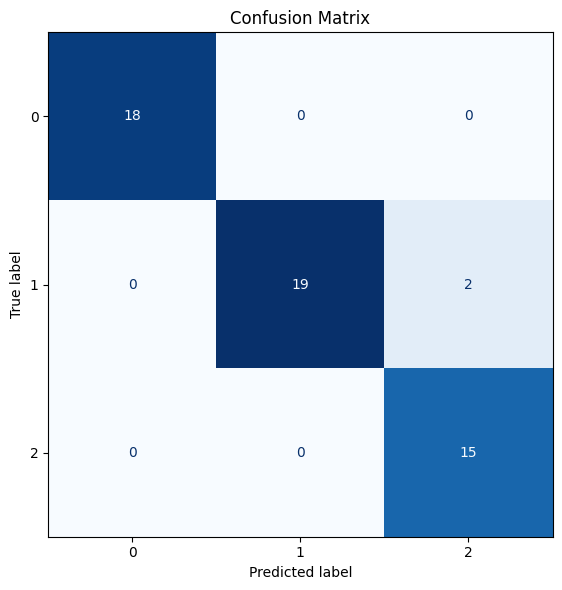

In [22]:
# Step 5: Evaluate using the stripped model
# - Use np.argmax for predictions
# - Print classification_report and confusion_matrix

test_loss, test_acc = stripped_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Pruned model test accuracy: {test_acc:.4f}")

y_pred_probs = stripped_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Problem 1 - Part (d)

### Knowledge Distillation

In [23]:
# Step 1: Define a Sequential model for Student with:
# - Dense(32, relu)
# - Dense(16, relu)
# - Dense(3, softmax)

student_model = Sequential([
    Dense(32, activation="relu", input_shape=(num_features,)),
    Dense(16, activation="relu"),
    Dense(num_classes, activation="softmax"),
])

student_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 32)                448       
                                                                 
 dense_7 (Dense)             (None, 16)                528       
                                                                 
 dense_8 (Dense)             (None, 3)                 51        
                                                                 
Total params: 1027 (4.01 KB)
Trainable params: 1027 (4.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [24]:
# Step 2: Use model.predict() on X_train_scaled to obtain teacher soft labels

teacher_preds_soft = model.predict(X_train, verbose=0)

In [25]:
# Step 3:
# (a) Concatenate hard (y_train_cat) and soft (teacher_preds_soft) labels along axis=1
#     to create a combined label for distillation
# (b) Define a custom distillation_loss() function that:
#     - Splits y_true_combined into y_true_hard and y_true_soft
#     - Computes two losses (both using categorical_crossentropy)
#     - Combines them with a weight factor alpha = 0.5

# Hint: Use slicing [:, :3] and [:, 3:] to split the combined labels

alpha = 0.5
y_train_combined = np.concatenate([y_train_cat, teacher_preds_soft], axis=1)

def distillation_loss(y_true_combined, y_pred):

    y_true_hard = y_true_combined[:, :num_classes]
    y_true_soft = y_true_combined[:, num_classes:]

    hard_loss = tf.keras.losses.categorical_crossentropy(y_true_hard, y_pred)
    soft_loss = tf.keras.losses.categorical_crossentropy(y_true_soft, y_pred)

    return alpha * hard_loss + (1.0 - alpha) * soft_loss

In [26]:
# Step 4: Compile the student model with Adam optimizer and distillation_loss
# - Train for 10 epochs, batch_size=8, validation_split=0.2

student_model.compile(
    optimizer="adam",
    loss=distillation_loss,
    metrics=["accuracy"],
)

history_kd = student_model.fit(
    X_train,
    y_train_combined,
    epochs=10,
    batch_size=8,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/10
13/13 [==============================] - 0s 4ms/step - loss: 1.0443 - accuracy: 0.4848 - val_loss: 0.9809 - val_accuracy: 0.5200
Epoch 2/10
13/13 [==============================] - 0s 957us/step - loss: 0.8890 - accuracy: 0.6162 - val_loss: 0.8437 - val_accuracy: 0.8000
Epoch 3/10
13/13 [==============================] - 0s 1ms/step - loss: 0.7671 - accuracy: 0.7576 - val_loss: 0.7268 - val_accuracy: 0.8800
Epoch 4/10
13/13 [==============================] - 0s 993us/step - loss: 0.6653 - accuracy: 0.8485 - val_loss: 0.6242 - val_accuracy: 0.9200
Epoch 5/10
13/13 [==============================] - 0s 1ms/step - loss: 0.5711 - accuracy: 0.9091 - val_loss: 0.5302 - val_accuracy: 0.9600
Epoch 6/10
13/13 [==============================] - 0s 986us/step - loss: 0.4863 - accuracy: 0.9495 - val_loss: 0.4494 - val_accuracy: 0.9600
Epoch 7/10
13/13 [==============================] - 0s 981us/step - loss: 0.4086 - accuracy: 0.9596 - val_loss: 0.3747 - val_accuracy: 0.9200
Epoch 8/10
1

In [27]:
# Step 5: Convert the student model to TFLite.
# - Save it as "model_kd.tflite".
# - Print the file size in KB.

converter = tf.lite.TFLiteConverter.from_keras_model(student_model)
kd_tflite_model = converter.convert()

kd_tflite_path = "model_kd.tflite"
with open(kd_tflite_path, "wb") as f:
    f.write(kd_tflite_model)

kd_size_kb = len(kd_tflite_model) / 1024.0
print(f"KD TFLite model saved to: {kd_tflite_path}")
print(f"KD model size: {kd_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpvxk80fqe/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpvxk80fqe/assets


KD TFLite model saved to: model_kd.tflite
KD model size: 6.10 KB


2026-05-07 18:20:10.116806: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-07 18:20:10.116815: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-07 18:20:10.116889: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpvxk80fqe
2026-05-07 18:20:10.117211: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-07 18:20:10.117215: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpvxk80fqe
2026-05-07 18:20:10.118080: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-07 18:20:10.131787: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpvxk80fqe
2026-05-

model size: 6.10 KB

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.95      0.95      0.95        21
           2       0.93      0.93      0.93        15

    accuracy                           0.96        54
   macro avg       0.96      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54


Confusion Matrix:


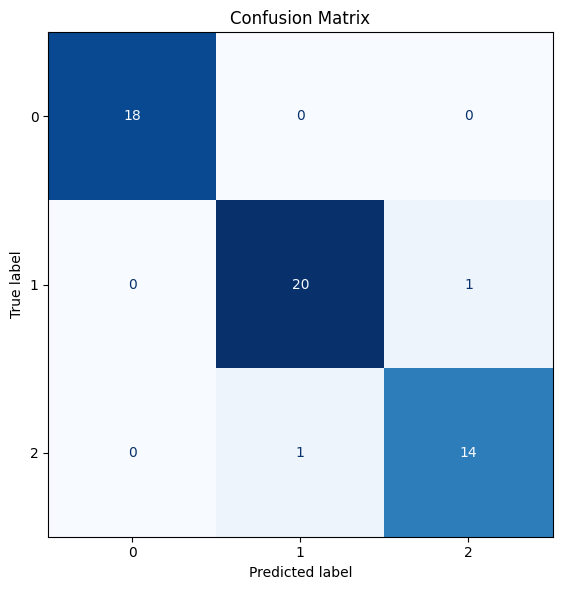

In [28]:
# Step 6: Use student_model.predict() to obtain predictions on X_test_scaled
# - Print classification_report and confusion_matrix

y_pred_probs = student_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
print(f"model size: {kd_size_kb:.2f} KB")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Problem 1 - Part (e)

### Possibility of Further Model Size Reduction

Can you **further reduce the model size** beyond the smallest model obtained in parts **(b)**, **(c)**, or **(d)**, **without sacrificing significant classification performance**?

Your task is to:

1. **Analyze and compare** the results from previous parts: Which model had the smallest size? Which performed best?

2. **Propose a strategy** that combines or enhances techniques learned so far.

3. **Implement** your proposed solution.

4. **Evaluate** the resulting model using both:
   - TFLite model size (in KB)
   - Classification performance (accuracy and report)

5. **Justify your results:**
   - If further size reduction is **not** possible without major loss of accuracy, explain why.
   - If you succeed in reducing the size **further**, highlight what change made the biggest difference.


### **Note:** If this part includes any code, please include it below. The related discussion should be submitted as part of your PDF that contains answers to all [Dis] questions in this assignment.


Epoch 1/15
13/13 [==============================] - 0s 4ms/step - loss: 0.1884 - accuracy: 0.9798 - val_loss: 0.1858 - val_accuracy: 0.9200
Epoch 2/15
13/13 [==============================] - 0s 1ms/step - loss: 0.1482 - accuracy: 0.9798 - val_loss: 0.1547 - val_accuracy: 0.9200
Epoch 3/15
13/13 [==============================] - 0s 1ms/step - loss: 0.1164 - accuracy: 0.9899 - val_loss: 0.1361 - val_accuracy: 0.9200
Epoch 4/15
13/13 [==============================] - 0s 991us/step - loss: 0.0951 - accuracy: 0.9899 - val_loss: 0.1208 - val_accuracy: 0.9200
Epoch 5/15
13/13 [==============================] - 0s 1ms/step - loss: 0.0795 - accuracy: 0.9899 - val_loss: 0.1158 - val_accuracy: 0.9200
Epoch 6/15
13/13 [==============================] - 0s 965us/step - loss: 0.0654 - accuracy: 0.9899 - val_loss: 0.1021 - val_accuracy: 0.9200
Epoch 7/15
13/13 [==============================] - 0s 946us/step - loss: 0.0543 - accuracy: 0.9899 - val_loss: 0.0931 - val_accuracy: 0.9200
Epoch 8/15
13/

INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpe0qkt00g/assets


Student + Pruning + INT8 model saved to: model_student_pruned_int8.tflite
Student + Pruning + INT8 model size: 3.62 KB
Student + Pruning + INT8 test accuracy: 0.9630

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.95      0.95      0.95        21
           2       0.93      0.93      0.93        15

    accuracy                           0.96        54
   macro avg       0.96      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



/Users/jimmyzheng/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-07 18:21:17.153988: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-07 18:21:17.153998: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-07 18:21:17.154075: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpe0qkt00g
2026-05-07 18:21:17.154316: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-07 18:21:17.154319: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpe0qkt00g
2026-05-07 18:21:17.154916: I tensorflow/cc/saved_model/loader.cc:23

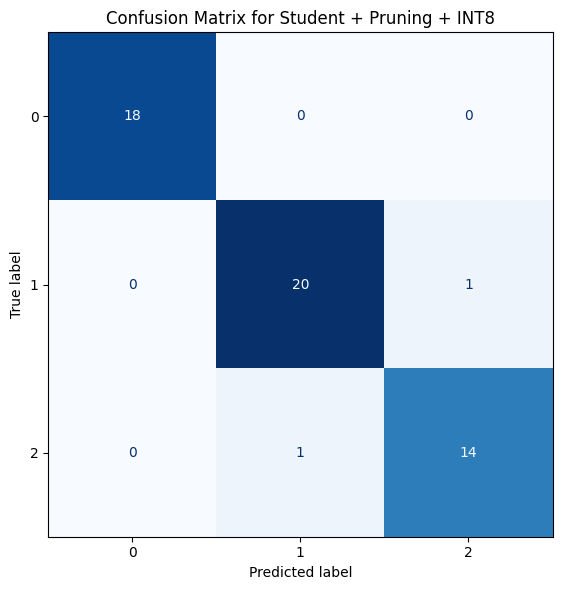

,Model,Model Size (KB),Test Accuracy
0,Part (b) INT8,5.740,1.000000
1,Student + Pruning + INT8,3.625,0.962963


In [30]:
pruning_epochs = 15
pruning_batch_size = 8
end_step = int(np.ceil(len(X_train) / pruning_batch_size) * pruning_epochs)

pruning_params = {
    "pruning_schedule": tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.2,
        begin_step=0,
        end_step=end_step
    )
}

#Clone the trained student model and wrap it with pruning

student_for_pruning = tf.keras.models.clone_model(student_model)
student_for_pruning.set_weights(student_model.get_weights())

pruned_student_model = tfmot.sparsity.keras.prune_low_magnitude(
    student_for_pruning,
    **pruning_params
)

pruned_student_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep()
]

pruned_student_history = pruned_student_model.fit(
    X_train,
    y_train_cat,
    epochs=pruning_epochs,
    batch_size=pruning_batch_size,
    validation_split=0.2,
    callbacks=pruning_callbacks,
    verbose=1,
)

#Strip pruning wrappers

stripped_student_model = tfmot.sparsity.keras.strip_pruning(pruned_student_model)

#convert the stripped pruned student to full INT8 TFLite

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_student_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = lambda: representative_data_gen(X_train)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

student_pruned_int8_tflite = converter.convert()

student_pruned_int8_path = "model_student_pruned_int8.tflite"
with open(student_pruned_int8_path, "wb") as f:
    f.write(student_pruned_int8_tflite)

student_pruned_int8_size_kb = len(student_pruned_int8_tflite) / 1024.0
print(f"Student + Pruning + INT8 model saved to: {student_pruned_int8_path}")
print(f"Student + Pruning + INT8 model size: {student_pruned_int8_size_kb:.2f} KB")

#Run TFLite inference on the INT8 model

interpreter = tf.lite.Interpreter(model_content=student_pruned_int8_tflite)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

input_scale, input_zero_point = input_details["quantization"]
output_scale, output_zero_point = output_details["quantization"]

y_pred = []

for i in range(len(X_test)):
    x = X_test[i:i+1].astype(np.float32)

    if input_details["dtype"] == np.int8:
        x = np.round(x / input_scale + input_zero_point).astype(np.int8)
    elif input_details["dtype"] == np.uint8:
        x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
    else:
        x = x.astype(input_details["dtype"])

    interpreter.set_tensor(input_details["index"], x)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details["index"])

    if output_details["dtype"] == np.int8:
        output = (output.astype(np.float32) - output_zero_point) * output_scale
    elif output_details["dtype"] == np.uint8:
        output = (output.astype(np.float32) - output_zero_point) * output_scale

    pred = int(np.argmax(output, axis=1)[0])
    y_pred.append(pred)

y_pred = np.array(y_pred)
y_true = np.argmax(y_test_cat, axis=1)

student_pruned_int8_acc = accuracy_score(y_true, y_pred)
print(f"Student + Pruning + INT8 test accuracy: {student_pruned_int8_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix for Student + Pruning + INT8")
plt.tight_layout()
plt.show()

# compare against the previous smallest model from Part (b)

comparison_extra = pd.DataFrame([
    ["Part (b) INT8", 5.74, 1.0000],
    ["Student + Pruning + INT8", student_pruned_int8_size_kb, student_pruned_int8_acc],
], columns=["Model", "Model Size (KB)", "Test Accuracy"])

comparison_extra

# Problem 2: Exploring Edge Impulse (20 points)


### Note

Problem 2 consists entirely of discussion questions. Submit your responses in the same PDF file that contains answers to the other **[Dis]** questions in this assignment.

Before submission, make sure this notebook runs with the **Python (tinyml-arduino)** kernel and that all requested outputs are visible. Host this notebook and your discussion PDF in your public GitHub repository, then submit the repository link through Canvas.
